## Peak performance of cube reduce kernel

> Copy versus `CubeReduce` kernel

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 11
plt.rcParams['lines.linewidth'] = 2.
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.5
_MARKERS = ["s", "^", "v", "<", ">", "o", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}


In [9]:
# Select plot parameters

# dtype = "int8"
dtype = "fp16"
tiles = [128]

In [24]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * df["in_bytes_per_elem"] + df["outputsize"] * nbytes_out_dtype
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [25]:
df.head()

,operator,dtype,size,density,outputsize,time_us,S,in_bytes_per_elem,mem_bytes,gelemps,bw_gbps
0,copy_fp16,fp16,81920,NaN,81920,29.03,memcopy,2,327680,2.821908,11.287633
1,copy_fp16,fp16,2703360,NaN,2703360,35.06,memcopy,2,10813440,77.106674,308.426697
2,copy_fp16,fp16,5324800,NaN,5324800,60.40,memcopy,2,21299200,88.158940,352.635762
3,copy_fp16,fp16,7946240,NaN,7946240,84.49,memcopy,2,31784960,94.049473,376.197893
4,copy_fp16,fp16,10567680,NaN,10567680,109.92,memcopy,2,42270720,96.139738,384.558952


In [26]:
PREFIX_PATH = "../../.."

df_copy = pd.read_csv(f"{PREFIX_PATH}/bench_results_copy_{dtype}.csv")
df_copy["S"] = "memcopy"
add_stats_siso(df_copy, 2)


df_tiled = pd.DataFrame()
for tile in tiles:
    df_tmp = pd.read_csv(f"{PREFIX_PATH}/bench_results_cube_reduce_{tile}_{dtype}.csv")
    df_tmp["S"] = f"s={tile}"
    df_tiled = pd.concat([df_tiled, df_tmp])


add_stats_siso(df_tiled, 2)

df = pd.concat([df_copy, df_tiled])

## Paper plots

/tmp/ipykernel_4191037/213304075.py:8: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)
/tmp/ipykernel_4191037/213304075.py:8: UserWarning: The markers list has more values (7) than needed (2), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)


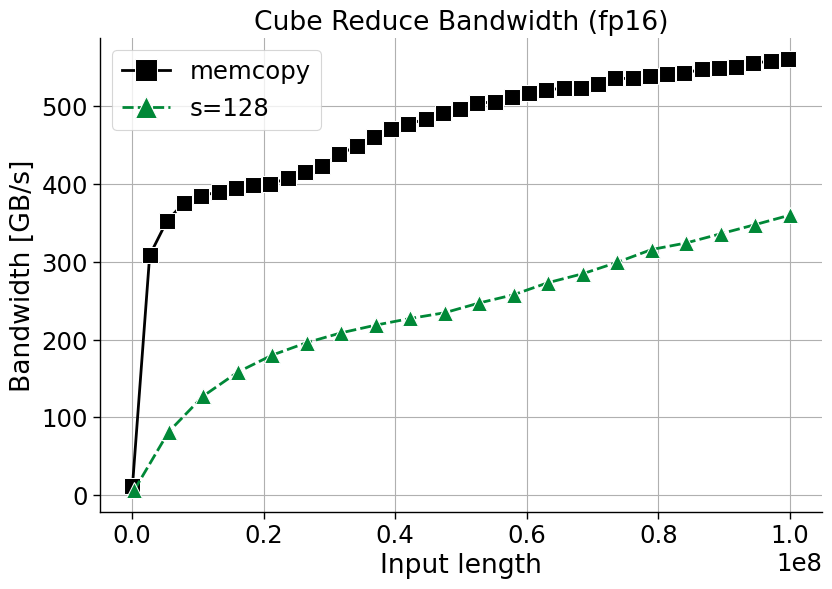

<Figure size 870x627 with 0 Axes>

In [28]:
palette = [### Colorbrewer colors
"black",
"#008837",
"#a6dba0",
"#c2a5cf",
"#7b3294",]

ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)

ax.set_title(f"Cube Reduce Bandwidth ({dtype})")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth [GB/s]")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/cube_reduce_{dtype}.png")
plt.show()
plt.clf()
